## Setup

### Environment

In [ ]:
# Install Libraries

!pip install torch==2.0.1 torchtext==0.15.2
!pip install portalocker==2.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Import Packages

import re
import time
import torch
import string


import numpy as np
import pandas as pd
import torch.nn as nn
import sentencepiece as spm
import matplotlib.pyplot as plt
import torch .nn. functional as F

from torchtext.datasets import IMDB
from torch.utils.data import Dataset
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# Determine device capabilities
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Handling Data

#### Import and Clean

In [ ]:
# Import datapipe and convert to dataframe

train_iter = IMDB(root='./datasets', split='train')
test_iter = IMDB(root='./datasets', split='test')

train_df = pd.DataFrame(train_iter)
train_df.columns = ['target', 'text']
train_df.insert(0, 'id', range(0, 0 + len(train_df)))

test_df = pd.DataFrame(test_iter)
test_df.columns = ['target', 'text']
test_df.insert(0, 'id', range(0, 0 + len(test_df)))

# Correct for index discrepancy
train_df['target'] = train_df['target'].map({2: 1, 1: 0})
test_df['target'] = test_df['target'].map({2: 1, 1: 0})
display(train_df)
display(test_df)

,id,target,text
0,0,0,I rented I AM CURIOUS-YELLOW from my video sto...
1,1,0,"""I Am Curious: Yellow"" is a risible and preten..."
2,2,0,If only to avoid making this type of film in t...
3,3,0,This film was probably inspired by Godard's Ma...
4,4,0,"Oh, brother...after hearing about this ridicul..."
...,...,...,...
24995,24995,1,A hit at the time but now better categorised a...
24996,24996,1,I love this movie like no other. Another time ...
24997,24997,1,This film and it's sequel Barry Mckenzie holds...
24998,24998,1,'The Adventures Of Barry McKenzie' started lif...


,id,target,text
0,0,0,I love sci-fi and am willing to put up with a ...
1,1,0,"Worth the entertainment value of a rental, esp..."
2,2,0,its a totally average film with a few semi-alr...
3,3,0,STAR RATING: ***** Saturday Night **** Friday ...
4,4,0,"First off let me say, If you haven't enjoyed a..."
...,...,...,...
24995,24995,1,Just got around to seeing Monster Man yesterda...
24996,24996,1,I got this as part of a competition prize. I w...
24997,24997,1,I got Monster Man in a box set of three films ...
24998,24998,1,"Five minutes in, i started to feel how naff th..."


In [ ]:
# Clean Text

def clean_text(text):
  '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
  text = str(text).lower()
  text = re.sub('\[.*?\]', '', text)
  text = re.sub('https?://\S+|www\.\S+', '', text)
  text = re.sub('<.*?>+', '', text)
  text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
  text = re.sub('\n', '', text)
  text = re.sub('\w*\d\w*', '', text)
  return text

train_df['text_clean'] = train_df['text'].apply(clean_text)
test_df['text_clean'] = test_df['text'].apply(clean_text)

#### Encoding

In [ ]:
# Define byte-pair encoding to create a predefined vocabulary

# Create directory for preprocessed text
!mkdir preprocessed_data
with open('preprocessed_data/train.txt', 'w') as f:
  for text in train_df['text_clean']:
    f.write(f'{text.strip()}\n')

VOCAB_SIZE = 8000
# Learn a BPE tokenization model
spm.SentencePieceTrainer.train(input='preprocessed_data/train.txt', model_prefix='bpe_model', vocab_size=VOCAB_SIZE, model_type='bpe')

sp = spm.SentencePieceProcessor(model_file='bpe_model.model')

def tokenize_into_str(text):
  return ' '.join(sp.encode(text, out_type=str))

def tokenize_into_idx(text):
  return ' '.join([str(tok) for tok in sp.encode(text)])

In [ ]:
# Encode training data
train_df['text_tokenized'] = train_df['text_clean'].apply(tokenize_into_str)
train_df['text_indices'] = train_df['text_clean'].apply(tokenize_into_idx)
train_df['text_indices'] = train_df['text_indices'].replace('', np.nan)
train_df.dropna(subset=['text_indices'], inplace=True)
display(train_df)

# Encode testing data
test_df['text_tokenized'] = test_df['text_clean'].apply(tokenize_into_str)
test_df['text_indices'] = test_df['text_clean'].apply(tokenize_into_idx)
test_df['text_indices'] = test_df['text_indices'].replace('', np.nan)
test_df.dropna(subset=['text_indices'], inplace=True)
display(test_df)

,id,target,text,text_clean,text_tokenized,text_indices
0,0,0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curiousyellow from my video stor...,▁i ▁rented ▁i ▁am ▁curious ye llow ▁from ▁my ▁...,6 3518 6 260 4297 4458 789 177 222 1251 2756 3...
1,1,0,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...,▁i ▁am ▁curious ▁yellow ▁is ▁a ▁ris ible ▁and ...,6 260 4297 7446 42 4 3926 661 30 4104 720 4879...
2,2,0,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...,▁if ▁only ▁to ▁avoid ▁making ▁this ▁type ▁of ▁...,214 266 32 2031 853 62 1671 33 89 40 7 1928 62...
3,3,0,This film was probably inspired by Godard's Ma...,this film was probably inspired by godards mas...,▁this ▁film ▁was ▁probably ▁inspired ▁by ▁god ...,62 89 78 815 3746 163 1271 1459 14 2034 128 11...
4,4,0,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing about this ridiculous ...,▁oh ▁brother after ▁hearing ▁about ▁this ▁ridi...,1388 1693 4148 4685 198 62 1663 89 85 6916 219...
...,...,...,...,...,...,...
24995,24995,1,A hit at the time but now better categorised a...,a hit at the time but now better categorised a...,▁a ▁hit ▁at ▁the ▁time ▁but ▁now ▁better ▁cate...,4 1373 120 7 261 105 540 470 3995 7989 24 1979...
24996,24996,1,I love this movie like no other. Another time ...,i love this movie like no other another time i...,▁i ▁love ▁this ▁movie ▁like ▁no ▁other ▁anothe...,6 418 62 100 172 220 326 620 261 6 285 1153 32...
24997,24997,1,This film and it's sequel Barry Mckenzie holds...,this film and its sequel barry mckenzie holds ...,▁this ▁film ▁and ▁its ▁sequel ▁barry ▁m ck en ...,62 89 30 151 1687 4799 14 116 21 7998 58 4107 ...
24998,24998,1,'The Adventures Of Barry McKenzie' started lif...,the adventures of barry mckenzie started life ...,▁the ▁adventures ▁of ▁barry ▁m ck en z ie ▁sta...,7 5007 33 4799 14 116 21 7998 58 1814 458 82 4...


,id,target,text,text_clean,text_tokenized,text_indices
0,0,0,I love sci-fi and am willing to put up with a ...,i love scifi and am willing to put up with a l...,▁i ▁love ▁scifi ▁and ▁am ▁willing ▁to ▁put ▁up...,6 418 2507 30 260 3706 32 758 240 94 4 536 250...
1,1,0,"Worth the entertainment value of a rental, esp...",worth the entertainment value of a rental espe...,▁worth ▁the ▁entertainment ▁value ▁of ▁a ▁rent...,783 7 1956 2720 33 4 4923 894 214 95 172 723 3...
2,2,0,its a totally average film with a few semi-alr...,its a totally average film with a few semialri...,▁its ▁a ▁totally ▁average ▁film ▁with ▁a ▁few ...,151 4 1452 2226 89 94 4 608 3739 599 1350 723 ...
3,3,0,STAR RATING: ***** Saturday Night **** Friday ...,star rating saturday night friday night fri...,▁star ▁rating ▁saturday ▁night ▁friday ▁night ...,787 1707 4819 813 5125 813 5125 4236 5471 813 ...
4,4,0,"First off let me say, If you haven't enjoyed a...",first off let me say if you havent enjoyed a v...,▁first ▁off ▁let ▁me ▁say ▁if ▁you ▁havent ▁en...,352 374 767 190 445 214 95 2020 1467 4 2043 17...
...,...,...,...,...,...,...
24995,24995,1,Just got around to seeing Monster Man yesterda...,just got around to seeing monster man yesterda...,▁just ▁got ▁around ▁to ▁seeing ▁monster ▁man ▁...,188 615 689 32 1030 2438 216 7668 46 268 342 4...
24996,24996,1,I got this as part of a competition prize. I w...,i got this as part of a competition prize i wa...,▁i ▁got ▁this ▁as ▁part ▁of ▁a ▁competition ▁p...,6 615 62 82 370 33 4 6879 1647 2628 6 945 46 1...
24997,24997,1,I got Monster Man in a box set of three films ...,i got monster man in a box set of three films ...,▁i ▁got ▁monster ▁man ▁in ▁a ▁box ▁set ▁of ▁th...,6 615 2438 216 40 4 1931 590 33 1021 382 446 6...
24998,24998,1,"Five minutes in, i started to feel how naff th...",five minutes in i started to feel how naff thi...,▁five ▁minutes ▁in ▁i ▁started ▁to ▁feel ▁how ...,2007 780 40 6 1814 32 508 257 3222 205 62 78 9...


In [ ]:
# Check Sequence Length
def count_tokens(text_indices):
  tokens = text_indices.split(' ')
  return len(tokens)

train_df['sequence_length'] = train_df['text_indices'].apply(count_tokens)
test_df['sequence_length'] = test_df['text_indices'].apply(count_tokens)

#### Saving and Final Preparation

In [ ]:
# Save Preprocessed data
X = train_df[[col for col in train_df.columns if not col == 'target']]
y = train_df['target']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)

train_data = pd.concat([X_train, y_train], axis=1)
print(train_data)
valid_data = pd.concat([X_valid, y_valid], axis=1)

# save them
train_data.to_pickle('preprocessed_data/train.pkl')
valid_data.to_pickle('preprocessed_data/valid.pkl')
test_df.to_pickle('preprocessed_data/test.pkl')

          id                                               text  \
6920    6920  What made me track this movie down was the vie...   
17926  17926  In ten words or less to describe this film, Ba...   
1123    1123  *****THIS REVIEW MAY HAVE SPOILERS - but that ...   
4518    4518  I can't believe that the City of Muncie is so ...   
5576    5576  This is the worst movie I have ever seen. The ...   
...      ...                                                ...   
21575  21575  My discovery of the cinema of Jan Svankmajer o...   
5390    5390  The story is similar to ET: an extraterrestria...   
860      860  I have read the novel Reaper of Ben Mezrich a ...   
15795  15795  Went to see this finnish film and I've got to ...   
23654  23654  I first saw "Breaking Glass" in 1980, and thou...   

                                              text_clean  \
6920   what made me track this movie down was the vie...   
17926  in ten words or less to describe this film bar...   
1123   this rev

In [ ]:
# Creating a custom dataset for consumption
class IMDBDataset(Dataset):
  def __init__(self, pickle_path):
    self.dataset = pd.read_pickle(pickle_path)

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    text_indices_string = self.dataset['text_indices'].iloc[idx]
    text_indices = [int(tok_idx) for tok_idx in text_indices_string.split(' ')]
    sequence_length = int(self.dataset['sequence_length'].iloc[idx])
    label = None
    if 'target' in self.dataset.columns:
      label = int(self.dataset['target'].iloc[idx])
    return text_indices, sequence_length, label

train_dataset = IMDBDataset('preprocessed_data/train.pkl')
valid_dataset = IMDBDataset('preprocessed_data/valid.pkl')
test_dataset = IMDBDataset('preprocessed_data/test.pkl')

In [ ]:
# Batching
def generate_batch(batch):
  batch_indices = []
  batch_labels = []
  offsets = [0]

  for text_indices, sequence_length, label in batch:
    batch_indices.extend(text_indices)
    batch_labels.append(label)
    offsets.append(sequence_length)

  batch_indices = torch.tensor(batch_indices, dtype=torch.long)
  batch_labels = torch.tensor(batch_labels, dtype=torch.long)
  offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
  return batch_indices, offsets, batch_labels



In [ ]:
# Final variables and reproduceability
BATCH_SIZE = 8
EMBED_DIM = 32
NUM_CLASS = 2

SEED = 42
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### Model Creation

In [ ]:
# Define MLP
class MLP(nn.Module):
  # hidden_dim defines the number of dimensions of the intermediate layer
  # if 0, which is the default, the MLP is defined as a single layer MLP with no intermediate layer
  def __init__(self, vocab_size, embed_dim, num_class, hidden_dim = 0) -> None:
    super().__init__()
    self.hidden_dim = hidden_dim
    self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=True)

    if hidden_dim == 0:
      self.fc1 = nn.Linear(embed_dim, num_class)
    else:
      self.fc1 = nn.Linear(embed_dim, hidden_dim)
      self.fc2 = nn.Linear(hidden_dim, num_class)

    # initialize weights
    self.init_weights()

  def init_weights(self):
    initrange = 0.5
    self.embedding.weight.data.uniform_(-initrange, initrange)
    self.fc1.weight.data.uniform_(-initrange, initrange)
    self.fc1.bias.data.zero_()
    if self.hidden_dim != 0:
      self.fc2.weight.data.uniform_(-initrange, initrange)
      self.fc2.bias.data.zero_()

  def forward(self, text, offsets):
    embedded = self.embedding(text, offsets)

    if self.hidden_dim == 0:
      return self.fc1(embedded)
    else:
      embedded = F.relu(self.fc1(embedded))
      return self.fc2(embedded)

  # Define Loss Function
  def train_func(self, train_loader):
    # Train the model
    train_loss = 0
    train_acc = 0
    total_size = 0
    for i, (text, offsets, cls) in enumerate(train_loader):
        total_size += len(cls)
        self.optimizer.zero_grad() #clear the gradients
        text, offsets, cls = text.to(device), offsets.to(device), cls.to(device)
        #forward pass
        output = self(text, offsets)
        #get the loss
        loss = self.criterion(output, cls)
        train_loss += loss.item()
        #calculate gradients
        loss.backward()
        #update weights
        self.optimizer.step()
        train_acc += (output.argmax(1) == cls).sum().item()
    # Adjust the learning rate
    self.scheduler.step()
    return train_loss / total_size, train_acc / total_size

  def valid_func(self, valid_loader):
    loss = 0
    acc = 0
    total_size = 0
    for text, offsets, cls in valid_loader:
      total_size += len(cls)
      text, offsets, cls = text.to(device), offsets.to(device), cls.to(device)
      with torch.no_grad():
        output = self(text, offsets)
        loss = self.criterion(output, cls)
        loss += loss.item()
        acc += (output.argmax(1) == cls).sum().item()
    return loss / total_size, acc / total_size

  def test_func(self, test_loader: DataLoader):
    loss = 0
    acc = 0
    total_size = 0
    incorrect_predictions = []
    for text, offsets, cls in test_loader:
      total_size += len(cls)
      text, offsets, cls = text.to(device), offsets.to(device), cls.to(device)
      with torch.no_grad():
        output = self(text, offsets)
        loss = self.criterion(output, cls)
        loss += loss.item()
        acc += (output.argmax(1) == cls).sum().item()

        for i in range(len(output)):
          if output.argmax(1)[i] != cls[i]:
            text_id = text[i].cpu().numpy()
            incorrect_predictions.append({
              'text': test_df['text'][text_id],  # Assuming text is a tensor
              'predicted_label': output.argmax(1)[i].item(),
              'true_label': cls[i].item()
            })
    self.test_results = pd.DataFrame(incorrect_predictions)
    return loss / total_size, acc / total_size

  def train_custom(self):
    N_EPOCHS = 25
    t = time.time()
    self.loss=[]
    self.acc=[]
    self.val_acc=[]
    self.test_acc = []

    min_valid_loss = float('inf')

    self.criterion = torch.nn.CrossEntropyLoss().to(device)
    self.optimizer = torch.optim.SGD(self.parameters(), lr=1.0)
    self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, 1, gamma=0.9)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=generate_batch)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=generate_batch)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=generate_batch)

    print(f'Number of Hidden Layers: {self.hidden_dim}')
    for epoch in range(N_EPOCHS):
      start_time = time.time()
      train_loss, train_acc = self.train_func(train_loader)
      valid_loss, valid_acc = self.valid_func(valid_loader)
      test_loss, test_acc = self.test_func(test_loader)

      print(f'\tEpoch Number: {epoch}')
      print(f'\t\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Val. Acc: {valid_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%')

      self.loss.append(train_loss)
      self.acc.append(train_acc)
      self.val_acc.append(valid_acc)
      self.test_acc.append(test_acc)

    print(f'time:{time.time()-t:.3f}')

  def generate_graph(self):
    plt.xlabel("runs")
    plt.ylabel("normalised measure of loss/accuracy")
    x_len=list(range(len(self.acc)))
    plt.axis([0, max(x_len), 0, 1])
    plt.title('result of MLP')
    loss=np.asarray(self.loss)/max(self.loss)
    plt.plot(x_len, self.loss, 'r.',label="loss")
    plt.plot(x_len, self.acc, 'b.', label="accuracy")
    plt.plot(x_len, self.val_acc, 'g.', label="val_accuracy")
    plt.plot(x_len, self.test_acc, 'm.', label="test_accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.2)
    plt.show



In [ ]:
# Create Models
model_single_layer = MLP(VOCAB_SIZE, EMBED_DIM, NUM_CLASS).to(device)
model_100_dim = MLP(VOCAB_SIZE, EMBED_DIM, NUM_CLASS, 100).to(device)
model_200_dim = MLP(VOCAB_SIZE, EMBED_DIM, NUM_CLASS, 200).to(device)

## Training

Number of Hidden Layers: 0
	Epoch Number: 0
		Train Loss: 0.070 | Train Acc: 69.30% | Val. Acc: 78.38% | Test Acc: 78.17%
	Epoch Number: 1
		Train Loss: 0.049 | Train Acc: 82.33% | Val. Acc: 83.18% | Test Acc: 82.88%
	Epoch Number: 2
		Train Loss: 0.041 | Train Acc: 86.06% | Val. Acc: 74.70% | Test Acc: 73.64%
	Epoch Number: 3
		Train Loss: 0.037 | Train Acc: 87.77% | Val. Acc: 83.20% | Test Acc: 82.44%
	Epoch Number: 4
		Train Loss: 0.034 | Train Acc: 88.90% | Val. Acc: 72.29% | Test Acc: 72.69%
	Epoch Number: 5
		Train Loss: 0.031 | Train Acc: 89.70% | Val. Acc: 86.75% | Test Acc: 86.32%
	Epoch Number: 6
		Train Loss: 0.030 | Train Acc: 90.44% | Val. Acc: 82.29% | Test Acc: 82.20%
	Epoch Number: 7
		Train Loss: 0.028 | Train Acc: 91.26% | Val. Acc: 86.72% | Test Acc: 85.73%
	Epoch Number: 8
		Train Loss: 0.026 | Train Acc: 91.80% | Val. Acc: 86.22% | Test Acc: 85.34%
	Epoch Number: 9
		Train Loss: 0.025 | Train Acc: 92.33% | Val. Acc: 87.65% | Test Acc: 87.07%
	Epoch Number: 10
		Tra

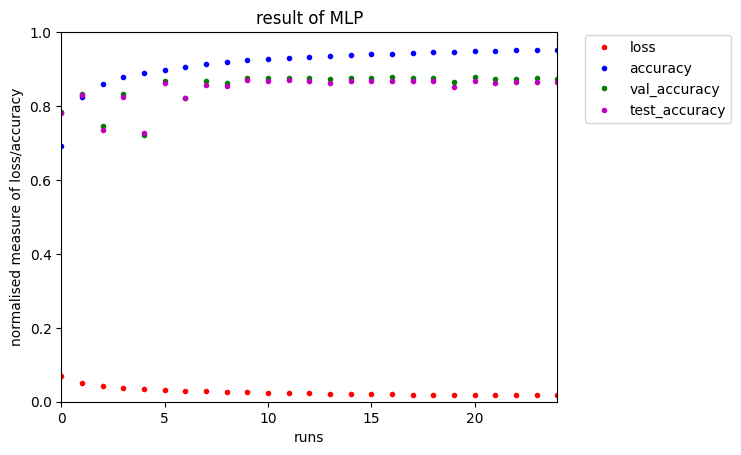

In [ ]:
#Training Execution, Single Layer
model_single_layer.train_custom()
model_single_layer.generate_graph()

In [ ]:
# Observe mistakes
display(model_single_layer.test_results)
# Observe single example in detail
example = model_single_layer.test_results.iloc[0]
display(example)
display(example['text'])

,text,predicted_label,true_label
0,If you are ever in the mood for a truly terrib...,1,0
1,"First off let me say, If you haven't enjoyed a...",1,0
2,"To remake ""Lost Horizon"", as a musical, the ne...",1,0
3,"This movie was awful, plain and simple! The an...",1,0
4,"I've become a big fan of the Carpenters, and I...",1,0
...,...,...,...
3354,I didn't expect a lot when i went out to see t...,0,1
3355,Art-house horror tries to use unconventional a...,0,1
3356,"I had this movie given to me, and have to admi...",0,1
3357,Overrated mob comedy. Director Demme makes the...,0,1


,0
text,If you are ever in the mood for a truly terrib...
predicted_label,1
true_label,0


'If you are ever in the mood for a truly terrible film, it would be hard to find something that could even compare to this. I have spent a lot of time watching a lot of terrible movies just for the sheer joy I get from it, and man, this is one of the worst. This movie was so bad, I had to buy the third Beastermaster online. That one wasn\'t as bad, which is amazing since it was straight to video. This is one of those films that is hard to comprehend how it was made in the first place. I mean, someone had to actually have read the script (or many scripts, I\'m sure they made several drafts) and said "Yeah, that\'s it. Here\'s some money." Actually, they probably just wanted to make a Beastmaster 2 before they even had a script, then went with whatever they had. Ack, horrible. So, if you are a fan of really bad movies, watch this one. It is a true classic, and film doesn\'t get much worse than this. And if it does, please let me know.'

Number of Hidden Layers: 100
	Epoch Number: 0
		Train Loss: 0.083 | Train Acc: 60.20% | Val. Acc: 73.76% | Test Acc: 74.33%
	Epoch Number: 1
		Train Loss: 0.059 | Train Acc: 78.30% | Val. Acc: 80.32% | Test Acc: 80.87%
	Epoch Number: 2
		Train Loss: 0.048 | Train Acc: 83.34% | Val. Acc: 65.14% | Test Acc: 64.91%
	Epoch Number: 3
		Train Loss: 0.043 | Train Acc: 85.86% | Val. Acc: 78.46% | Test Acc: 78.69%
	Epoch Number: 4
		Train Loss: 0.038 | Train Acc: 87.56% | Val. Acc: 76.78% | Test Acc: 75.64%
	Epoch Number: 5
		Train Loss: 0.034 | Train Acc: 88.72% | Val. Acc: 85.70% | Test Acc: 84.98%
	Epoch Number: 6
		Train Loss: 0.032 | Train Acc: 89.75% | Val. Acc: 86.88% | Test Acc: 86.49%
	Epoch Number: 7
		Train Loss: 0.030 | Train Acc: 90.36% | Val. Acc: 82.56% | Test Acc: 81.37%
	Epoch Number: 8
		Train Loss: 0.028 | Train Acc: 91.19% | Val. Acc: 86.91% | Test Acc: 86.54%
	Epoch Number: 9
		Train Loss: 0.026 | Train Acc: 91.77% | Val. Acc: 84.19% | Test Acc: 83.60%
	Epoch Number: 10
		T

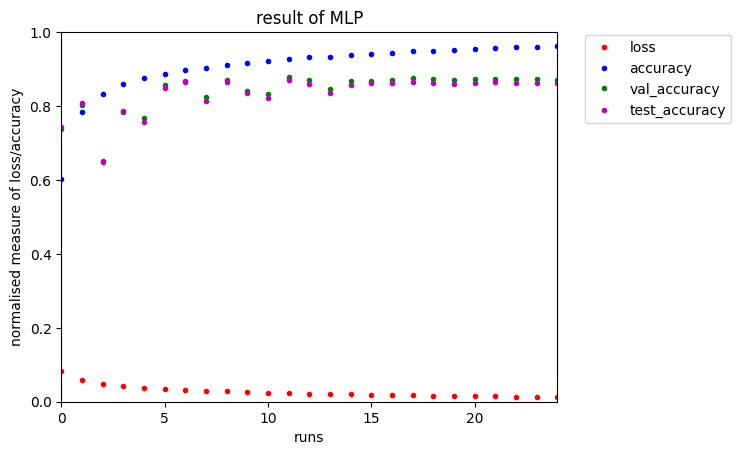

In [ ]:
#Training Execution, Two Layers, 100 Dimension Intermediate Layer
model_100_dim.train_custom()
model_100_dim.generate_graph()

Number of Hidden Layers: 200
	Epoch Number: 0
		Train Loss: 0.084 | Train Acc: 58.65% | Val. Acc: 54.50% | Test Acc: 55.01%
	Epoch Number: 1
		Train Loss: 0.061 | Train Acc: 76.58% | Val. Acc: 76.91% | Test Acc: 77.38%
	Epoch Number: 2
		Train Loss: 0.049 | Train Acc: 82.83% | Val. Acc: 84.78% | Test Acc: 84.62%
	Epoch Number: 3
		Train Loss: 0.042 | Train Acc: 85.43% | Val. Acc: 84.82% | Test Acc: 84.50%
	Epoch Number: 4
		Train Loss: 0.038 | Train Acc: 87.35% | Val. Acc: 86.37% | Test Acc: 86.14%
	Epoch Number: 5
		Train Loss: 0.035 | Train Acc: 88.53% | Val. Acc: 86.30% | Test Acc: 85.92%
	Epoch Number: 6
		Train Loss: 0.032 | Train Acc: 89.40% | Val. Acc: 86.78% | Test Acc: 85.93%
	Epoch Number: 7
		Train Loss: 0.030 | Train Acc: 90.26% | Val. Acc: 87.02% | Test Acc: 86.96%
	Epoch Number: 8
		Train Loss: 0.028 | Train Acc: 91.17% | Val. Acc: 82.54% | Test Acc: 82.14%
	Epoch Number: 9
		Train Loss: 0.026 | Train Acc: 91.67% | Val. Acc: 80.88% | Test Acc: 79.42%
	Epoch Number: 10
		T

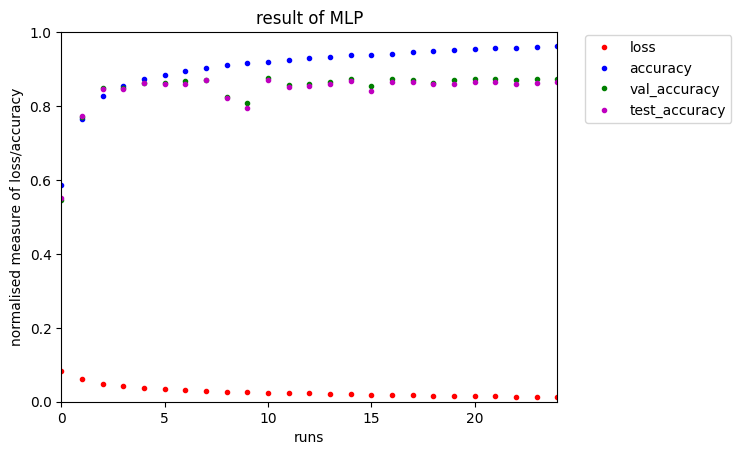

In [ ]:
#Training Execution, Two Layers, 200 Dimension Intermediate Layer
model_200_dim.train_custom()
model_200_dim.generate_graph()

## Analysis

Brandon Hawfitch, hawfi004

My task for Natural Language Processing Homework 1 was to create and execute a series of neural networks with different parameters, for the purpose of identifying positive or negative sentiments from within a predefined text datset.

This assignment was conducted on Google Colab, utilizing the T4 GPU hardware runtime.

The dataset in question utilized for this assignment is the torchtext IMDB movie review dataset ([documented here](https://pytorch.org/text/stable/datasets.html#imdb)). The dataset contains 25000 training samples and 25000 testing samples, each labelled with either a 1 or 2 to indicate the target sentiment.

The networks designed in this document are simple multilayer perceptrons with fully connected layers. Each network utilizes EmbeddingBag ([documented here](https://pytorch.org/docs/stable/generated/torch.nn.EmbeddingBag.html)) for embedding the first layer, and uses a vocab size of 8000 and embed dimensions of 32. The output layer consists of 2 classes indicating positive or negative sentiment, and the network runs 25 epochs for training. Batches are provided in sets of 8 movie reviews. The networks utilize the ReLU activation function when they consist of more than a single layer.

The first network consists of a single layer. At the end of its execution it achieves a training loss of 0.017, a training accuracy of 95.22%, a validation accuracy of 87.66%, and a testing accuracy of 86.44%. This network executed in approximately 255 seconds.

The second network is a two-layer MLP utilizing a 100 dimensional hidden layer. At the end of its execution it achieves a training loss of 0.013, a training accuracy of 96.21%, a validation accuracy of 86.21%, and a testing accuracy of 84.61%. This network executed in approximately 268 seconds.

The third network is a two-layer MLP utilizing a 200 dimensional hidden layer. At the end of its execution it achieves a training loss of 0.012, a training accuracy of 96.34%, a validation accuracy of 87.31%, and a testing accuracy of 86.30%. This network executed in approximately 271 seconds.

<br>

|                            | Training Loss | Training Accuracy | Validation Accuracy | Test Accuracy | Runtime (seconds) |
|----------------------------|---------------|-------------------|---------------------|---------------|-------------------|
| Network 1 (Single Layer)   | 0.017         | 95.22%            | 87.66%              | 86.44%        | 327               |
| Network 2 (100 Hidden Dim) | 0.013         | 96.21%            | 86.21%              | 84.61%        | 364               |
| Network 3 (200 Hidden Dim) | 0.012         | 96.34%            | 87.31%              | 86.30%        | 350               |

<br>

We can observe that, in terms of the training, the two layer networks surpass the single layer network more significantly in terms of loss and accuracy, with the difference between the deeper networks being less significant. Regarding validation and testing accuracy, it appears as though the 100 dimension two-layer network actually suffers in comparison to both the single-layer and higher dimensional two-layer networks. The biggest observable difference between the two-layer networks is that the 200 dimensioned network appears less stable, as its accuracy varies more from epoch to epoch.

When we look at a single example of a mistaken label from the single layer test data set, it's hard not to be a little understanding. In said example, the author describes the experience of watching a "terrible" movie as a delightful experience. Despite the language of how it's the perfect choice, this is within the context of if the reader is looking for a terrible movie. Given the specific choice of language and the importance of the context, it makes sense that the neural network may not observe the subtleties involved.

In conclusion, all networks were effective in training, and "learned" to classify correctly approximately 85% of the time. While increasing the depth of the network and the dimensionality of its hidden layers did improve performance on training, this was not necessarily the story when it came to validation and testing. All three networks appeared to stabilize in performance around 5 epochs, after which there was little variation.